### Problem Statement

You are a data scientist working on a classification problem to predict whether a hotel reservation will be canceled or not. You have been provided with a dataset named **`"hotel_reservations.csv"`**, which includes various attributes related to hotel bookings. The dataset comprises the following columns:

- `booking_id:` unique identifier of each booking
- `no_of_adults:` Number of adults
- `no_of_children:` Number of Children
- `no_of_weekend_nights:` Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
- `no_of_week_nights:` Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
- `type_of_meal_plan:` Type of meal plan booked by the customer
- `required_car_parking_space:` Does the customer require a car parking space? (0 - No, 1- Yes)
- `room_type_reserved:` Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels
- `lead_time:` Number of days between the date of booking and the arrival date
- `arrival_year:` Year of arrival date
- `arrival_month:` Month of arrival date
- `arrival_date:` Date of the month
- `market_segment_type:` Market segment designation
- `repeated_guest:` Is the customer a repeated guest? (0 - No, 1- Yes)
- `no_of_previous_cancellations:` Number of previous bookings that were canceled by the customer prior to the current booking
- `no_of_previous_bookings_not_canceled:` Number of previous bookings not canceled by the customer prior to the current booking
- `avg_price_per_room:` Average price per day of the reservation; prices of the rooms are dynamic (in euros)
- `no_of_special_requests:` Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
- `booking_status:` Flag indicating if the booking was canceled or not (Not_Canceled = 0, Canceled = 1)


You will perform data preprocessing, exploratory data analysis, and model training using different algorithms, including logistic regression, decision tree, random forest, and Naive Bayes. Additionally, you will implement k-fold cross-validation, stratified k-fold cross-validation, grid search, and randomized search techniques.

**Dataset Credits:** Ahsan Raza (https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset)

**Import Necessary Libraries**


In [154]:
# Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1: Data Preprocessing and EDA

1. Import the data from the `"hotel_reservations.csv"` file and store it in a variable df.
2. Display the number of rows and columns in the dataset.
3. Display the first few rows of the dataset to get an overview.
5. Remove the columns `booking_id, arrival_year, arrival_month, and arrival_date` as they do not add significant value to the predictive model.
6. Visualize the booking_status using a count plot.
7. Visualize the lead time for canceled and not canceled bookings using a box plot.
8. Visualize the average price per room for canceled and not canceled bookings using a box plot.
9. Encode categorical variables: type_of_meal_plan, room_type_reserved, and market_segment_type using one-hot encoding.

In [155]:
# Import the data from the "hotel_reservations.csv" file and store it in a variable df.
df = pd.read_csv("hotel_reservations.csv")

# Display the number of rows and columns in the dataset
print(df.shape)

# Display the first few rows of the dataset to get an overview
df.head()

(36275, 19)


,booking_id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [156]:
# Remove the columns booking_id, arrival_year, arrival_month, and arrival_date
df.drop(["booking_id", "arrival_year", "arrival_month", "arrival_date"], inplace=True, axis=1)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,Online,0,0,0,94.50,0,Canceled


<Axes: xlabel='booking_status', ylabel='Count'>

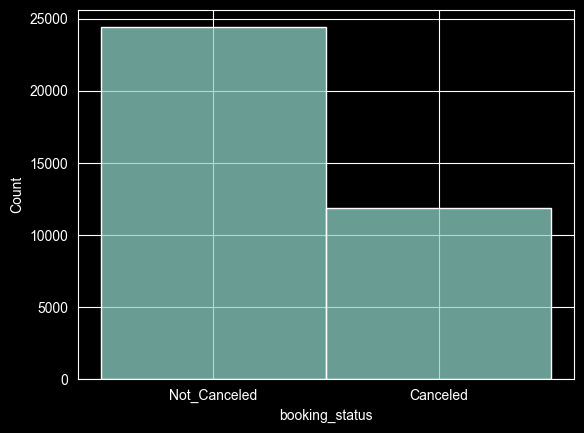

In [157]:
# Visualize the booking_status
# df["booking_status"].hist()
# plt.hist(df["booking_status"])
sns.histplot(data=df, x="booking_status", bins=20)

<Axes: xlabel='booking_status', ylabel='lead_time'>

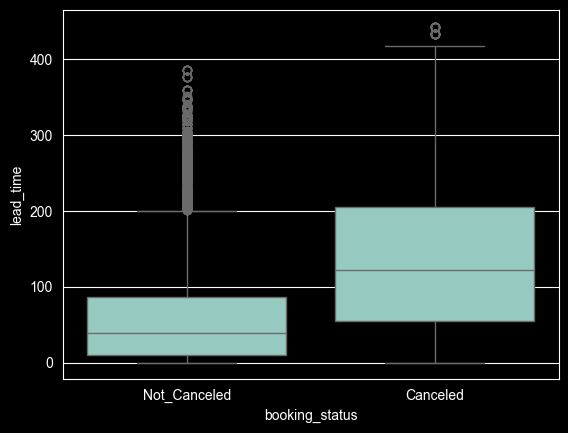

In [158]:
# Visualize the lead time for canceled and not canceled bookings using a box plot
sns.boxplot(data=df, x="booking_status", y="lead_time" )

<Axes: xlabel='booking_status', ylabel='avg_price_per_room'>

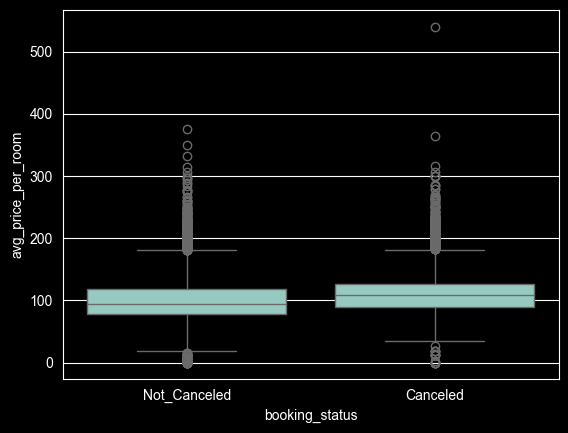

In [159]:
# Visualize the average price per room for canceled and not canceled bookings. sns.boxplot(x='booking_status', y='avg_price_per_room', data=df)
sns.boxplot(x='booking_status', y='avg_price_per_room', data=df)


In [160]:
# Encode categorical variables : type_of_meal_plan, room_type_reserved, and market_segment_type using one-hot encoding.
df = pd.get_dummies(data=df, columns=['type_of_meal_plan', "room_type_reserved", "market_segment_type"], drop_first=True)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,0,0,0,65.00,...,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,0,0,0,106.68,...,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,0,0,0,60.00,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,0,0,0,100.00,...,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,0,0,0,94.50,...,False,False,False,False,False,False,False,False,False,True


### Task 2: Feature Scaling

1. Standardize the numerical features `lead_time` and `avg_price_per_room`.
2. Define features (X) and target (y).

In [161]:
df[["lead_time", "avg_price_per_room"]].head()

,lead_time,avg_price_per_room
0,224,65.00
1,5,106.68
2,1,60.00
3,211,100.00
4,48,94.50


In [162]:
df["booking_status"].unique()

<StringArray>
['Not_Canceled', 'Canceled']
Length: 2, dtype: str

In [163]:
# Standardize the numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[["lead_time", "avg_price_per_room"]] = scaler.fit_transform(df[["lead_time", "avg_price_per_room"]])
print(df[["lead_time", "avg_price_per_room"]].head(2))

# Define features(X) and target (y: booking_status)
X = df.drop("booking_status", axis=1)
y = df["booking_status"]


   lead_time  avg_price_per_room
0   1.614896           -1.095033
1  -0.933701            0.092806


### Task 3: Implementing K-Fold Cross Validation

1. Initialize a KFold cross-validator with 7 splits.
2. Perform k-fold cross-validation using Naive Bayes and calculate the average accuracy.
3. Perform k-fold cross-validation using a Logistic Regression and calculate the average accuracy.
4. Perform k-fold cross-validation using a decision tree classifier and calculate the average accuracy.

In [164]:

# Initialize KFold with 7 splits.
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

kf = KFold(n_splits=7, random_state=42, shuffle=True)

# Cross validation with Naive Bayes
nb_score = cross_val_score(GaussianNB(), X, y, cv=kf)

# Cross validation with Logistic Regression
log_score = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=kf)

# Cross validation with Decision Tree

dt_score = cross_val_score(DecisionTreeClassifier(), X, y, cv=kf)

# xg_score = cross_val_score(XGBClassifier(), X, y, cv=kf)

print("Naive Bayes avg score" , np.average(nb_score))
print("Logistic regression avg score" , np.average(log_score))
print("Decision tree avg score" , np.average(dt_score))
# print("XgBoost avg score" , np.average(xg_score))

Naive Bayes avg score 0.4086008945293444
Logistic regression avg score 0.8004685935356991
Decision tree avg score 0.8567059186192053


### Task 4: Implementing Stratified K-Fold Cross Validation

1. Initialize a StratifiedKFold cross-validator with 7 splits
2. Perform stratified k-fold cross-validation using Naive Bayes and calculate the average accuracy.
3. Perform stratified k-fold cross-validation using a Logistic Regression and calculate the average accuracy.
4. Perform stratified k-fold cross-validation using a Decision Tree classifier and calculate the average accuracy.

In [165]:
from sklearn.model_selection import StratifiedKFold
# Initialize a StratifiedKFold cross-validator with 7 splits
skf = StratifiedKFold(n_splits=7, random_state=42, shuffle=True)

# Cross validation with Naive Bayes
nb_score = cross_val_score(GaussianNB(), X, y, cv=skf)

# Cross validation with Logistic Regression
log_score = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=skf)

# Cross validation with Decision Tree

dt_score = cross_val_score(DecisionTreeClassifier(), X, y, cv=skf)

# xg_score = cross_val_score(XGBClassifier(), X, y, cv=kf)

print("Naive Bayes avg score" , np.average(nb_score))
print("Logistic regression avg score" , np.average(log_score))
print("Decision tree avg score" , np.average(dt_score))
# print("XgBoost avg score" , np.average(xg_score))


Naive Bayes avg score 0.40862851035462067
Logistic regression avg score 0.799669202624214
Decision tree avg score 0.8593796698442986


### Task 5: Implementing Grid Search CV

1. Initialize GridSearchCV with Naive Bayes and Random Forest:
    - Naive Bayes: var_smoothing [1e-9, 1e-8, 1e-7]
    - Random Forest: n_estimators [10, 50, 100], max_depth [5, 10, 15]
<br></br>
2. Fit GridSearchCV with Naive Bayes and Random Forest, and find the best parameters.
3. Print the best parameters for each model.

In [172]:
# Initialize GridSearchCV with Naive Bayes and Random Forest 
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

model_params = {
     'naive_bayes': {
        'model': GaussianNB(),
        'params' : {
            'var_smoothing': [1e-9, 1e-8, 1e-7]
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'n_estimators': [10, 50, 100],
            'max_depth': [5, 10, 15]
        }
    }
}


# Fit GridSearchCV with Naive Bayes and Random Forest, and find the best parameters.

scores  = []
for key, val in model_params.items():
    clf = GridSearchCV(val["model"], val["params"])
    clf.fit(X, y)
    scores.append({
        'model': key,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })


# Print the best parameters for each model.
df_scores = pd.DataFrame(scores, columns=["model", "best_score", "best_params"])
df_scores

,model,best_score,best_params
0,naive_bayes,0.409373,{'var_smoothing': 1e-07}
1,random_forest,0.875672,"{'max_depth': 15, 'n_estimators': 100}"


### Task 6: Implementing Randomized Search CV

1. Initialize RandomizedSearchCV for RandomForest with the given parameters:
   - Random Forest: n_estimators [10, 50, 100], max_depth [5, 10, 15, 20]
<br></br>
2. Fit RandomizedSearchCV with RandomForest model and find the best parameters.
2. Print the best parameters.

In [167]:
# Initialize RandomizedSearchCV and fit with RandomForest model


# Print Best Parameters
